## 1. Data Understanding - Target Variable dan Hubungan Bivariate

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Setting untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Load dataset
df = pd.read_csv('data-bank.csv')
print("✓ Dataset berhasil dimuat")

# Kolom pertama adalah target variable
target_col = df.columns[0]

# Analisis korelasi dengan target
correlation_with_target = df.corr()[target_col].drop(target_col).sort_values(ascending=False)

✓ Dataset berhasil dimuat


Box plot saved as boxplot_bivariate.png


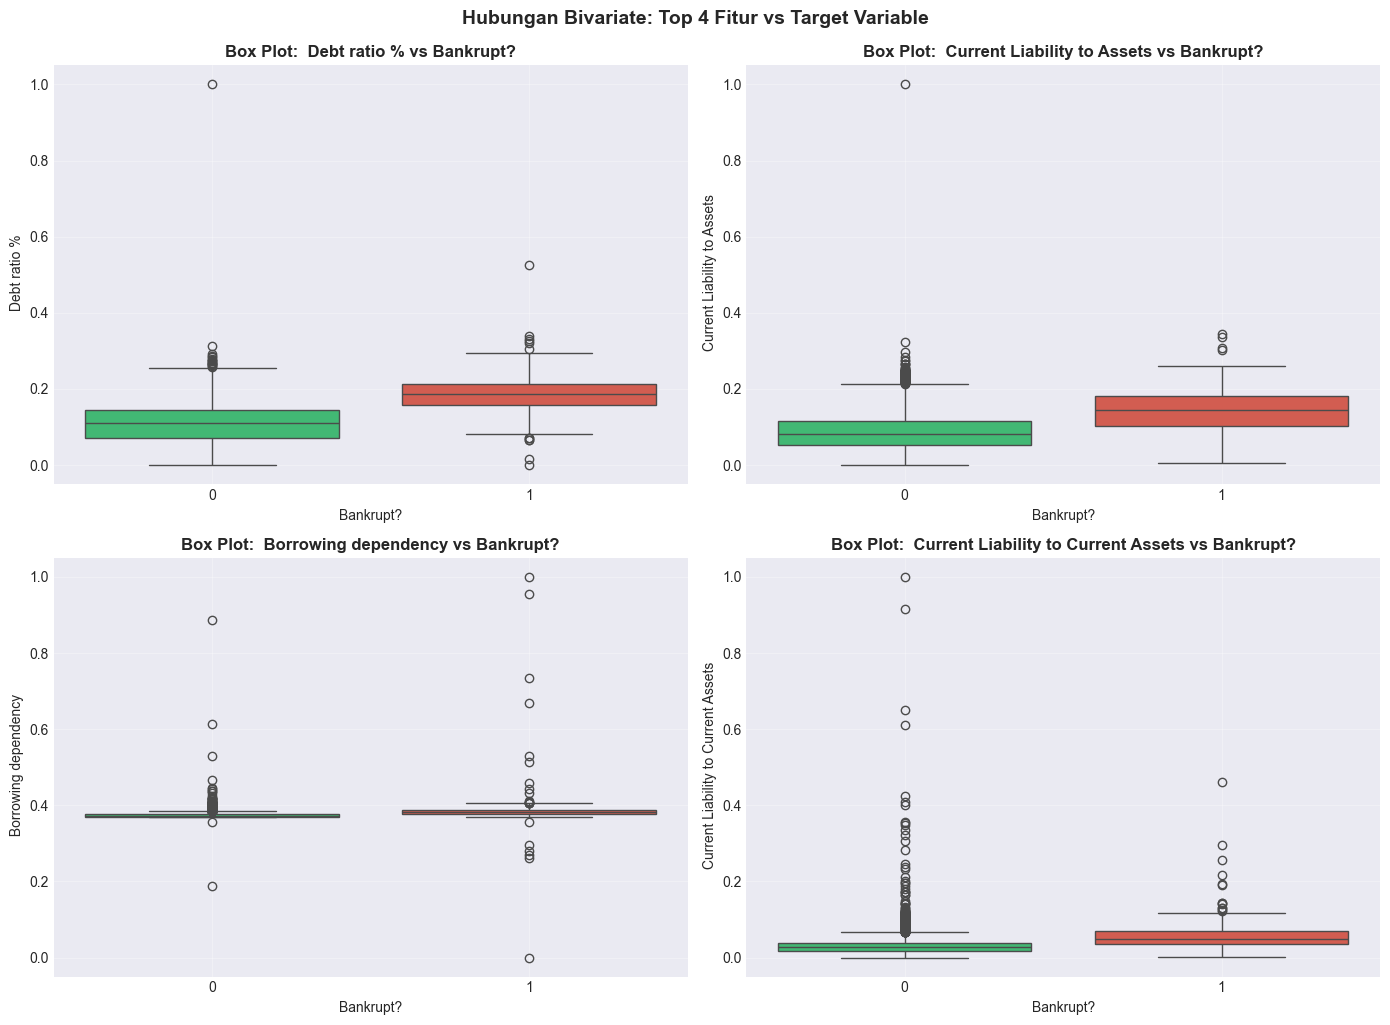

In [4]:
# Visualisasi hubungan bivariate: Box plot untuk beberapa fitur vs target
# Pilih 4 fitur dengan korelasi tertinggi
top_features = correlation_with_target.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(top_features):
    sns.boxplot(x=target_col, y=feature, data=df, ax=axes[i], hue=target_col, palette=['#2ecc71', '#e74c3c'], legend=False)
    axes[i].set_title(f'Box Plot: {feature} vs {target_col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(target_col)
    axes[i].set_ylabel(feature)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Hubungan Bivariate: Top 4 Fitur vs Target Variable', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('boxplot_bivariate.png')
print("Box plot saved as boxplot_bivariate.png")
plt.show()

Scatter plot saved as scatterplot_bivariate.png


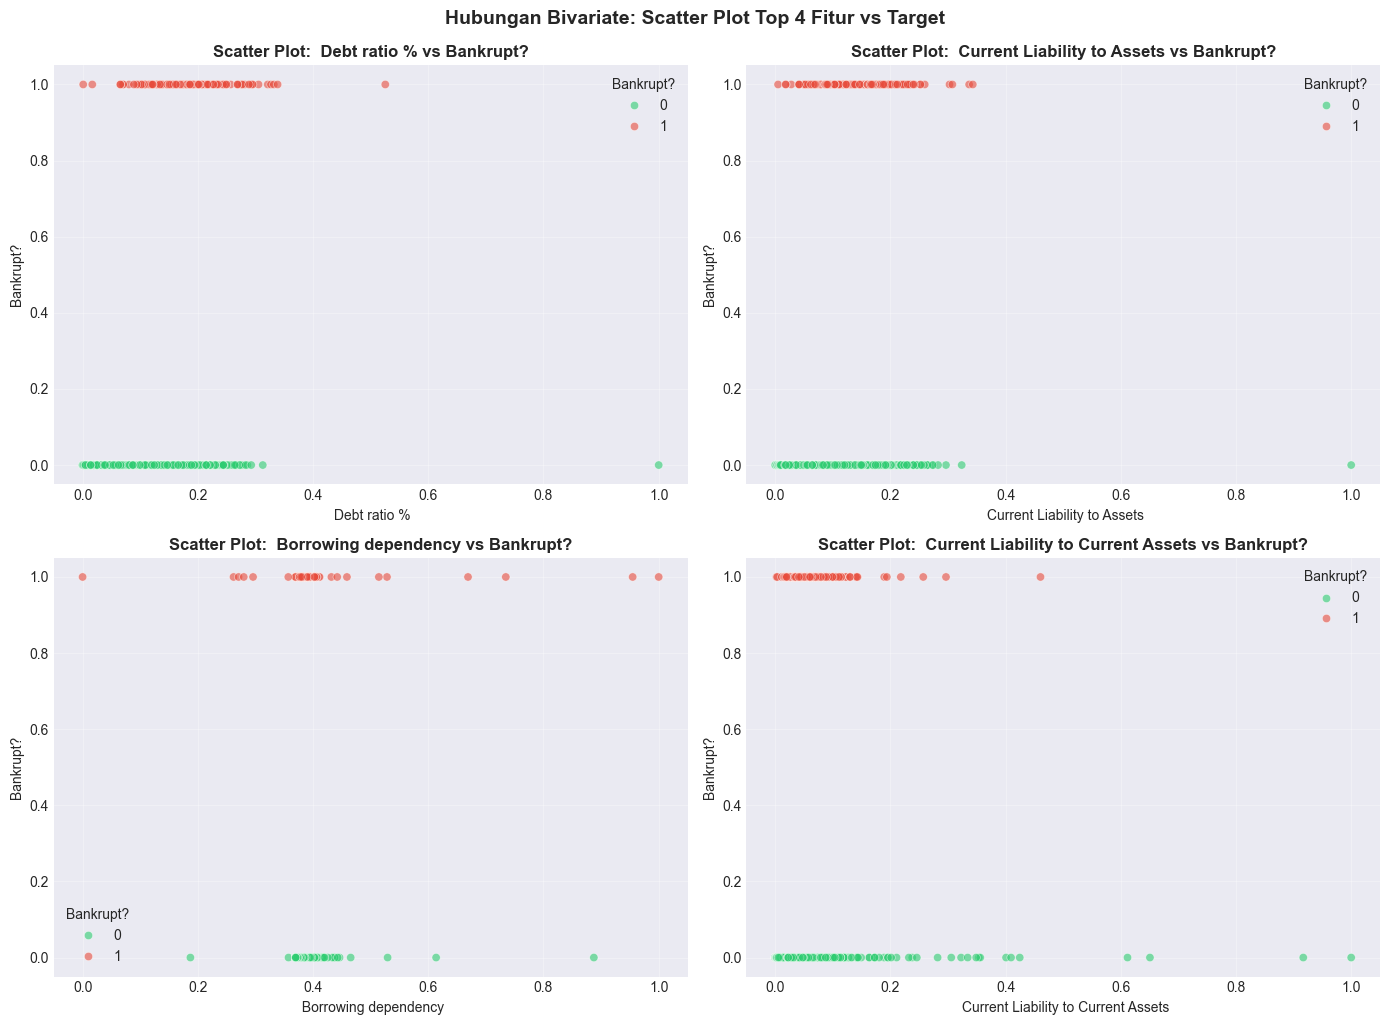

In [5]:
# Visualisasi hubungan bivariate: Scatter plot untuk fitur numerik vs target
# Gunakan fitur dengan korelasi tinggi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(top_features):
    sns.scatterplot(x=feature, y=target_col, data=df, ax=axes[i], alpha=0.6, hue=target_col, palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'Scatter Plot: {feature} vs {target_col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target_col)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Hubungan Bivariate: Scatter Plot Top 4 Fitur vs Target', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('scatterplot_bivariate.png')
print("Scatter plot saved as scatterplot_bivariate.png")
plt.show()

Heatmap saved as heatmap_correlation.png


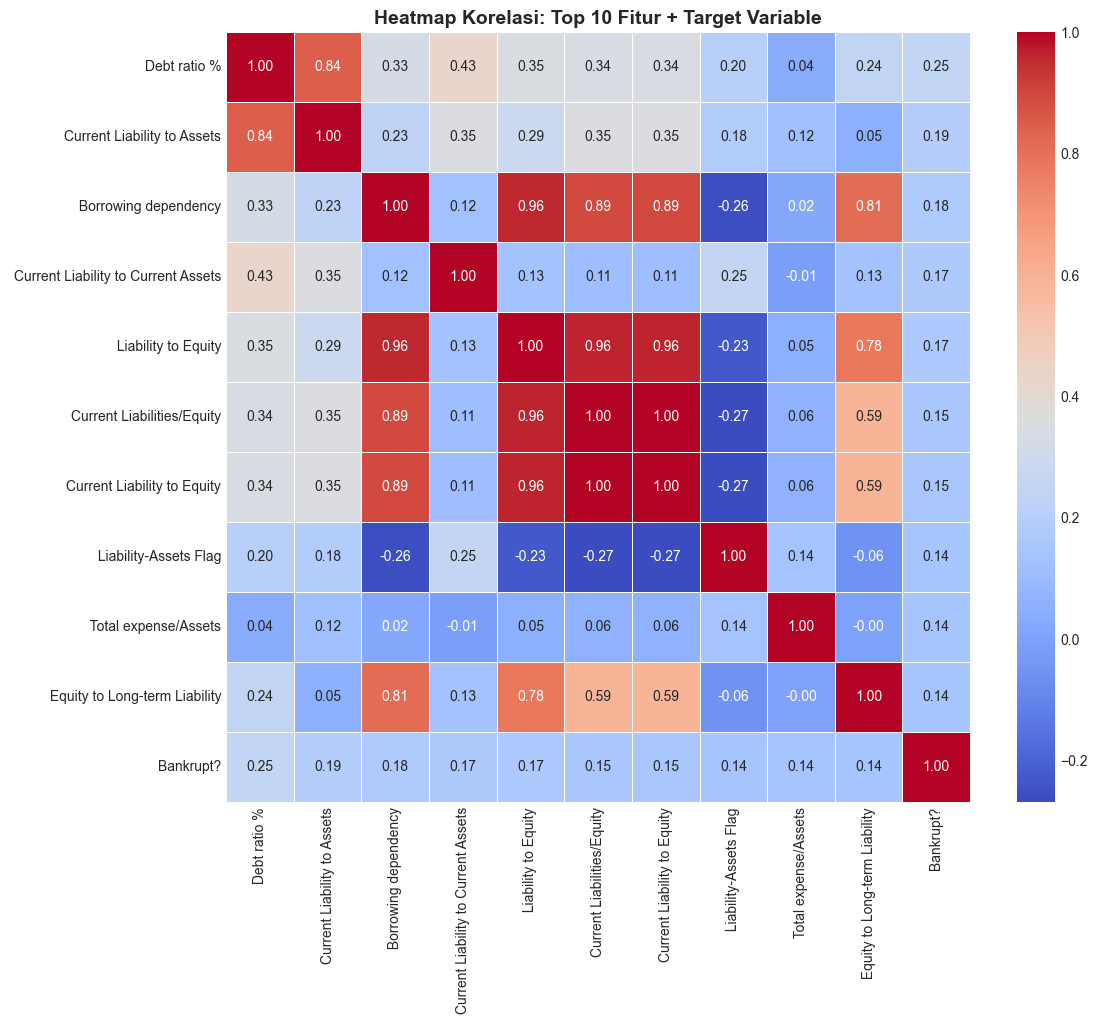

In [6]:
# Heatmap korelasi untuk top 10 fitur + target
top_10_features = correlation_with_target.head(10).index.tolist()
corr_matrix = df[top_10_features + [target_col]].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi: Top 10 Fitur + Target Variable', fontsize=14, fontweight='bold')
plt.savefig('heatmap_correlation.png')
print("Heatmap saved as heatmap_correlation.png")
plt.show()

## 2. Data Preparation - Balance Check, Data Cleaning, dan Data Transformation

Distribusi Target Variable:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Persentase:
Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11772\1368949869.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette=['#2ecc71', '#e74c3c'])


Target distribution saved as target_distribution.png


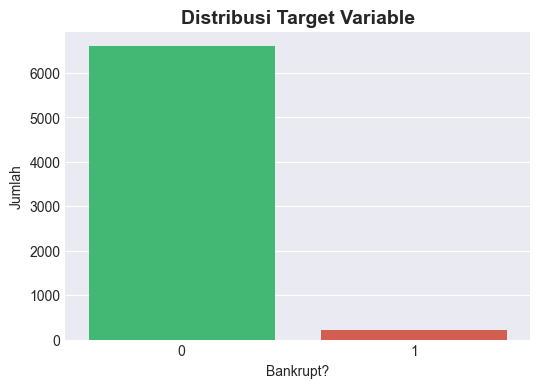


Ratio kelas minoritas/mayoritas: 0.033
Dataset sangat imbalance (highly imbalanced).


In [2]:
# Cek balance dataset
print("Distribusi Target Variable:")
print(df[target_col].value_counts())
print("\nPersentase:")
print(df[target_col].value_counts(normalize=True) * 100)

# Visualisasi distribusi target
plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribusi Target Variable', fontsize=14, fontweight='bold')
plt.xlabel(target_col)
plt.ylabel('Jumlah')
plt.savefig('target_distribution.png')
print("Target distribution saved as target_distribution.png")
plt.show()

# Kesimpulan balance
balance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nRatio kelas minoritas/mayoritas: {balance_ratio:.3f}")
if balance_ratio < 0.1:
    print("Dataset sangat imbalance (highly imbalanced).")
elif balance_ratio < 0.5:
    print("Dataset imbalance.")
else:
    print("Dataset balance.")

In [3]:
# Data Cleaning

# 1. Cek missing values
print("Missing Values per Kolom:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# 2. Cek duplicates
duplicates = df.duplicated().sum()
print(f"\nJumlah baris duplikat: {duplicates}")

# 3. Cek data types
print("\nData Types:")
print(df.dtypes)

# 4. Cek outliers menggunakan IQR untuk fitur numerik
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("\nOutliers Detection (IQR method) untuk top 5 fitur:")
for feature in correlation_with_target.head(5).index:
    num_outliers, lb, ub = detect_outliers_iqr(df, feature)
    print(f"{feature}: {num_outliers} outliers (LB: {lb:.3f}, UB: {ub:.3f})")

# Cleaning: Hapus duplicates jika ada
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"\nDuplicates dihapus. Dataset sekarang: {df.shape}")

# Untuk missing values, jika ada, kita bisa impute (tapi di dataset ini kemungkinan tidak ada)
# df.fillna(df.mean(), inplace=True)  # Contoh impute mean untuk numerik

Missing Values per Kolom:
Series([], dtype: int64)

Total missing values: 0

Jumlah baris duplikat: 0

Data Types:
Bankrupt?                                                     int64
 ROA(C) before interest and depreciation before interest    float64
 ROA(A) before interest and % after tax                     float64
 ROA(B) before interest and depreciation after tax          float64
 Operating Gross Margin                                     float64
 Realized Sales Gross Margin                                float64
 Operating Profit Rate                                      float64
 Pre-tax net Interest Rate                                  float64
 After-tax net Interest Rate                                float64
 Non-industry income and expenditure/revenue                float64
 Continuous interest rate (after tax)                       float64
 Operating Expense Rate                                     float64
 Research and development expense rate                      float64
 

In [4]:
# Data Transformation

# 1. Normalisasi/Standardisasi fitur numerik
from sklearn.preprocessing import StandardScaler

# Pilih fitur numerik (semua kecuali target jika target kategorikal, tapi di sini target numerik)
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_features:
    numeric_features.remove(target_col)  # Exclude target jika ingin

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])

print("Data setelah standardisasi (head):")
print(df_scaled[numeric_features].head())

# 2. Encoding jika ada fitur kategorikal (di dataset ini semua numerik, jadi tidak perlu)

# 3. Feature Engineering (contoh: log transform untuk fitur skewed)
# Misal untuk fitur dengan distribusi skewed
skewed_features = df[numeric_features].skew().abs().sort_values(ascending=False)
print(f"\nFitur dengan skewness tinggi (>1): {skewed_features[skewed_features > 1].index.tolist()}")

# Contoh log transform untuk fitur positif
for feature in skewed_features[skewed_features > 1].index[:2]:  # Ambil 2 contoh
    if (df[feature] > 0).all():  # Pastikan positif
        df_scaled[f'{feature}_log'] = np.log1p(df[feature])
        print(f"Log transform applied to {feature}")

# Simpan dataset yang sudah dibersihkan dan ditransformasi
df_scaled.to_csv('data-bank_cleaned.csv', index=False)
print("\nDataset cleaned dan transformed disimpan sebagai 'data-bank_cleaned.csv'")

Data setelah standardisasi (head):
   ROA(C) before interest and depreciation before interest  \
0                                          -2.217909         
1                                          -0.673828         
2                                          -1.303672         
3                                          -1.735886         
4                                          -0.661778         

   ROA(A) before interest and % after tax  \
0                               -2.045798   
1                               -0.311068   
2                               -0.908420   
3                               -1.636209   
4                               -0.307745   

   ROA(B) before interest and depreciation after tax  Operating Gross Margin  \
0                                          -2.400361               -0.383334   
1                                          -0.598450                0.135068   
2                                          -1.319910               -0.383759   
3

Distribusi sebelum SMOTE: Counter({0: 6599, 1: 220})
Distribusi setelah SMOTE: Counter({1: 6599, 0: 6599})

Dataset balanced shape: (13198, 96)
Distribusi setelah SMOTE: Counter({1: 6599, 0: 6599})

Dataset balanced shape: (13198, 96)
Dataset balanced disimpan sebagai 'data-bank_balanced.csv'
Balanced target distribution saved as target_distribution_balanced.png
Dataset balanced disimpan sebagai 'data-bank_balanced.csv'
Balanced target distribution saved as target_distribution_balanced.png


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11772\2852916385.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df_balanced, palette=['#2ecc71', '#e74c3c'])


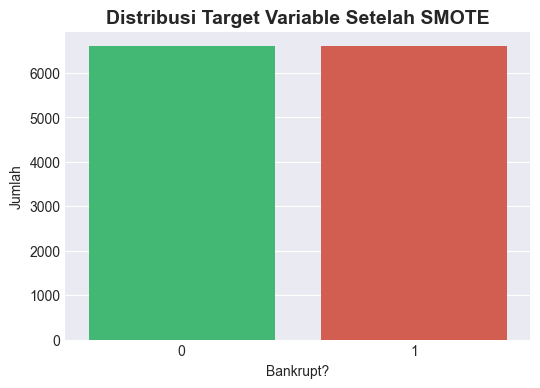

In [5]:
# Handling Imbalanced Data

# Karena dataset imbalance, gunakan teknik oversampling dengan SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

# Pisahkan fitur dan target
X = df_scaled[numeric_features]
y = df_scaled[target_col]

print("Distribusi sebelum SMOTE:", Counter(y))

# Terapkan SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print("Distribusi setelah SMOTE:", Counter(y_smote))

# Buat dataframe baru
df_balanced = pd.DataFrame(X_smote, columns=numeric_features)
df_balanced[target_col] = y_smote

print(f"\nDataset balanced shape: {df_balanced.shape}")

# Simpan dataset balanced
df_balanced.to_csv('data-bank_balanced.csv', index=False)
print("Dataset balanced disimpan sebagai 'data-bank_balanced.csv'")

# Visualisasi distribusi setelah balancing
plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df_balanced, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribusi Target Variable Setelah SMOTE', fontsize=14, fontweight='bold')
plt.xlabel(target_col)
plt.ylabel('Jumlah')
plt.savefig('target_distribution_balanced.png')
print("Balanced target distribution saved as target_distribution_balanced.png")
plt.show()

## 3. Modelling - Random Forest, Decision Tree, dan Artificial Neural Network

In [6]:
# Import library untuk modelling
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# Load dataset balanced
df_model = pd.read_csv('data-bank_balanced.csv')
print("Dataset balanced dimuat, shape:", df_model.shape)

# Pisahkan fitur dan target
X = df_model.drop(target_col, axis=1)
y = df_model[target_col]

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Standardisasi untuk ANN
scaler_model = StandardScaler()
X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)

Dataset balanced dimuat, shape: (13198, 96)
Train shape: (10558, 95), Test shape: (2640, 95)


In [7]:
# Model 1: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)  # Batasi depth untuk hindari overfit
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

print("=== Decision Tree ===")
print("Classification Report:")
print(classification_report(y_test, dt_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, dt_proba):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

=== Decision Tree ===
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      1320
           1       0.92      0.97      0.94      1320

    accuracy                           0.94      2640
   macro avg       0.94      0.94      0.94      2640
weighted avg       0.94      0.94      0.94      2640

ROC-AUC: 0.9453
Confusion Matrix:
[[1211  109]
 [  43 1277]]


In [8]:
# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("\n=== Random Forest ===")
print("Classification Report:")
print(classification_report(y_test, rf_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))


=== Random Forest ===
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.97      1320
           1       0.95      0.99      0.97      1320

    accuracy                           0.97      2640
   macro avg       0.97      0.97      0.97      2640
weighted avg       0.97      0.97      0.97      2640

ROC-AUC: 0.9953
Confusion Matrix:
[[1247   73]
 [  11 1309]]


In [9]:
# Model 3: Artificial Neural Network (menggunakan MLPClassifier dari sklearn)
from sklearn.neural_network import MLPClassifier

ann_model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=500, random_state=42)
ann_model.fit(X_train_scaled, y_train)
ann_pred = ann_model.predict(X_test_scaled)
ann_proba = ann_model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Artificial Neural Network (MLP) ===")
print("Classification Report:")
print(classification_report(y_test, ann_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, ann_proba):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, ann_pred))


=== Artificial Neural Network (MLP) ===
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1320
           1       0.98      1.00      0.99      1320

    accuracy                           0.99      2640
   macro avg       0.99      0.99      0.99      2640
weighted avg       0.99      0.99      0.99      2640

ROC-AUC: 0.9933
Confusion Matrix:
[[1292   28]
 [   0 1320]]



=== Perbandingan Model ===
           Model  Accuracy   ROC-AUC
0  Decision Tree  0.942424  0.945275
1  Random Forest  0.968182  0.995344
2      ANN (MLP)  0.989394  0.993264
ROC curves saved as roc_curves_comparison.png


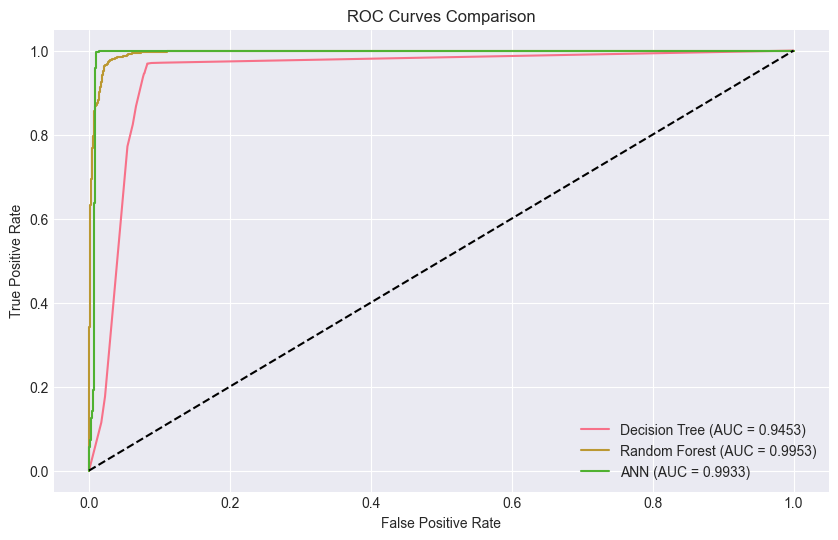


Algoritma paling sesuai: Random Forest (berdasarkan ROC-AUC tertinggi)


In [10]:
# Perbandingan Model
models = ['Decision Tree', 'Random Forest', 'ANN (MLP)']
accuracies = [
    dt_model.score(X_test, y_test),
    rf_model.score(X_test, y_test),
    ann_model.score(X_test_scaled, y_test)
]
roc_aucs = [
    roc_auc_score(y_test, dt_proba),
    roc_auc_score(y_test, rf_proba),
    roc_auc_score(y_test, ann_proba)
]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies,
    'ROC-AUC': roc_aucs
})
print("\n=== Perbandingan Model ===")
print(comparison_df)

# Visualisasi ROC Curve
plt.figure(figsize=(10, 6))
for name, proba in [('Decision Tree', dt_proba), ('Random Forest', rf_proba), ('ANN', ann_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, proba):.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.savefig('roc_curves_comparison.png')
print("ROC curves saved as roc_curves_comparison.png")
plt.show()

# Kesimpulan
best_model = comparison_df.loc[comparison_df['ROC-AUC'].idxmax(), 'Model']
print(f"\nAlgoritma paling sesuai: {best_model} (berdasarkan ROC-AUC tertinggi)")

## 4. Evaluation - Evaluasi Model dengan Confusion Matrix, Precision, Recall, F1-Score

Confusion Matrix for Decision Tree saved as confusion_matrix_decision_tree.png


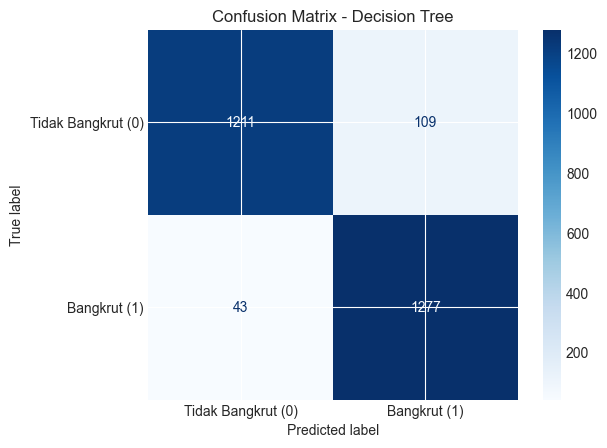

Confusion Matrix for Random Forest saved as confusion_matrix_random_forest.png


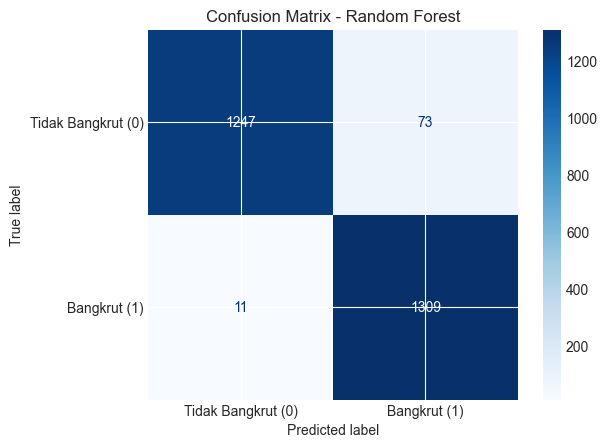

Confusion Matrix for ANN (MLP) saved as confusion_matrix_ann_(mlp).png


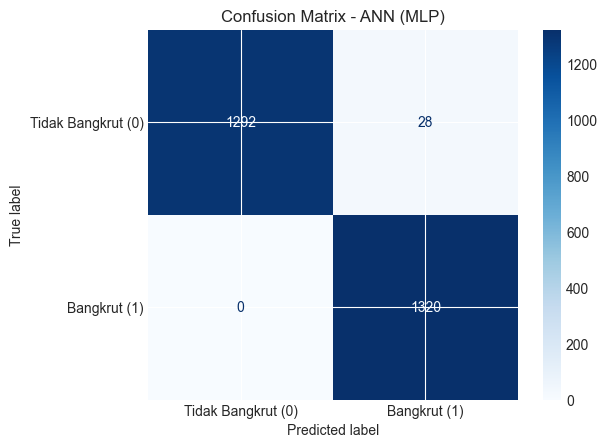

In [11]:
# Import untuk visualisasi evaluasi
from sklearn.metrics import ConfusionMatrixDisplay

# Fungsi untuk plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Bangkrut (0)', 'Bangkrut (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.savefig(f'confusion_matrix_{model_name.lower().replace(" ", "_")}.png')
    print(f"Confusion Matrix for {model_name} saved as confusion_matrix_{model_name.lower().replace(' ', '_')}.png")
    plt.show()

# Plot untuk Decision Tree
plot_confusion_matrix(y_test, dt_pred, 'Decision Tree')

# Plot untuk Random Forest
plot_confusion_matrix(y_test, rf_pred, 'Random Forest')

# Plot untuk ANN
plot_confusion_matrix(y_test, ann_pred, 'ANN (MLP)')

In [12]:
# Summary Metrics Lengkap
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = ['Decision Tree', 'Random Forest', 'ANN (MLP)']
predictions = [dt_pred, rf_pred, ann_pred]
probas = [dt_proba, rf_proba, ann_proba]

summary_metrics = []
for name, pred, proba in zip(models, predictions, probas):
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, proba)
    summary_metrics.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

summary_df = pd.DataFrame(summary_metrics)
print("=== Summary Metrics ===")
print(summary_df.round(4))

# Detailed Classification Reports
print("\n=== Detailed Classification Reports ===")
for name, pred in zip(models, predictions):
    print(f"\n{name}:")
    print(classification_report(y_test, pred))

=== Summary Metrics ===
           Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Decision Tree    0.9424     0.9214  0.9674    0.9438   0.9453
1  Random Forest    0.9682     0.9472  0.9917    0.9689   0.9953
2      ANN (MLP)    0.9894     0.9792  1.0000    0.9895   0.9933

=== Detailed Classification Reports ===

Decision Tree:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      1320
           1       0.92      0.97      0.94      1320

    accuracy                           0.94      2640
   macro avg       0.94      0.94      0.94      2640
weighted avg       0.94      0.94      0.94      2640


Random Forest:
              precision    recall  f1-score   support

           0       0.99      0.94      0.97      1320
           1       0.95      0.99      0.97      1320

    accuracy                           0.97      2640
   macro avg       0.97      0.97      0.97      2640
weighted avg       0.97      0.97      0.97 

In [15]:
# Top 5 variabel yang paling mempengaruhi kebangkrutan
print("Top 5 variabel dengan korelasi tertinggi terhadap target 'Bankrupt?':")
top_5_features = correlation_with_target.head(5)
for i, (feature, corr) in enumerate(top_5_features.items(), 1):
    print(f"{i}. {feature}: Korelasi = {corr:.4f}")

Top 5 variabel dengan korelasi tertinggi terhadap target 'Bankrupt?':
1.  Debt ratio %: Korelasi = 0.2502
2.  Current Liability to Assets: Korelasi = 0.1945
3.  Borrowing dependency: Korelasi = 0.1765
4.  Current Liability to Current Assets: Korelasi = 0.1713
5.  Liability to Equity: Korelasi = 0.1668
